# 08-Reranking (Cross-Encoders)

In Lesson 07, we engineered a **Hybrid Search** system using Reciprocal Rank Fusion (RRF). By merging the conceptual understanding of Dense vectors with the exact token-matching precision of Sparse BM25, we successfully generated a candidate pool of documents.

However, both Bi-Encoders and BM25 suffer from a foundational architectural constraint: they evaluate documents **in isolation**.

* A Bi-Encoder processes the query $q$ and a document $d$ separately, mapping them to single vector representations before taking a simple dot product. The query tokens never directly "talk" to the document tokens inside the hidden layers of the neural network.
* BM25 merely tallies word intersections.

Because of this isolation, if a document contains a complex semantic structure—such as a critical negation (*"Do NOT use this configuration if the server is running version 2"*), or a highly hidden piece of information buried deep inside a 5,000-word file—the initial retrieval systems can easily misrank it. This phenomenon is known as the **"Needle in a Haystack"** or **"Lost in the Middle"** problem.

To achieve surgical precision, we must ingest the top $K$ candidate documents (typically the top 25 to 100 results from the Hybrid stage) and pass them through a final validation checkpoint: the **Cross-Encoder Reranker**.

Let's set up our environment to analyze the deep attention mechanics of Cross-Encoders.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Reranking Environment Ready.")

✅ Systems Architecture & Reranking Environment Ready.


# 1. Bi-Encoders vs. Cross-Encoders: The Token-Interaction Physics

The core difference between a Bi-Encoder and a Cross-Encoder lies entirely in where and when the **Self-Attention Mechanism** occurs.

### Bi-Encoder Topology (Isolated Encoding)

The query and the document are fed into two separate Transformer networks (or the same network via twin forward passes).

$$\mathbf{h}_q = \text{Transformer}(q), \quad \mathbf{h}_d = \text{Transformer}(d)$$

$$\text{Score}(q, d) = \langle \mathbf{h}_q, \mathbf{h}_d \rangle$$

* **Advantage**: Since $\mathbf{h}_d$ can be pre-computed and indexed inside an ANN graph (HNSW), searching 100 million documents takes only 5 milliseconds.
* **Disadvantage**: Zero cross-attention. The query tokens cannot influence how the document tokens are weighted during the deep neural extraction layers.

### Cross-Encoder Topology (Joint Encoding)

The query $q$ and the document $d$ are packed together into a single, unified token sequence separated by a special token (e.g., `[SEP]`), and passed into a single Transformer network simultaneously.

$$\text{Input} = [\text{CLS}] \, q_1 \, q_2 \, \dots \, q_m \, [\text{SEP}] \, d_1 \, d_2 \, \dots \, d_n \, [\text{SEP}]$$

$$\mathbf{h}_{\text{joint}} = \text{Transformer}(\text{Input})$$

$$\text{Score}(q, d) = \sigma(\mathbf{W} \cdot \mathbf{h}_{[\text{CLS}]})$$

* **Advantage**: Full token-to-token cross-attention. Every single word in the query directly calculates an attention weight against every single word in the document at *every single layer* of the neural network. Negations, complex dependencies, and buried facts are processed with maximum cognitive depth.
* **Disadvantage**: Extreme computational cost. To evaluate $N$ documents, you must run $N$ complete forward passes through a large deep learning Transformer model. Running this across 100 million documents would crash your infrastructure and take hours per query.

```
BI-ENCODER (Fast / Isolated):
Query ----> [ Transformer ] ----> Vector \
                                          (Dot Product) ---> Similarity
Document -> [ Transformer ] ----> Vector /

CROSS-ENCODER (Slow / Deep Cross-Attention):
[ Query + Document ] ----> [ Transformer (Full Attention) ] ----> Classification Score

# 2. The $\mathcal{O}(N)$ Multi-Stage Search Architecture

To balance execution latency with architectural accuracy, production RAG systems deploy a **Multi-Stage Retrieval Funnel**:

1. **Stage 1 (The Wide Net)**: Use a fast Hybrid (Dense + Sparse) index to search across millions of documents. This narrows down the pool from **100,000,000 to 50 candidates** in under 10ms.
2. **Stage 2 (The Deep Clean)**: Take those 50 candidates and run them through a Cross-Encoder Reranker. This sorts the final 50 with near-perfect accuracy in roughly 30ms.

# 3. Architecting the Two-Stage Reranking Pipeline

Let's simulate this multi-stage retrieval funnel. We will create a query, execute an initial fast retrieval that falls victim to a semantic blind spot, and then deploy a cross-attention reranker model to rescue the correct document from the bottom of the list.

In [2]:
# --- 🧠 The Two-Stage Reranking Simulation ---

class MockCrossEncoderReranker:
    """
    Simulates a deep Transformer Cross-Encoder that reads the query and document 
    together to detect subtle linguistic dependencies and negations.
    """
    def __init__(self):
        # Hardcoded heuristic weights to simulate deep token interaction
        pass

    def compute_cross_attention_score(self, query: str, document: str) -> float:
        q_clean = query.lower()
        d_clean = document.lower()
        
        # Base semantic match
        score = 0.0
        words = q_clean.split()
        for w in words:
            if w in d_clean:
                score += 1.0
                
        # Simulate deep linguistic negation analysis
        # If the query asks for "without" or "no" and the document addresses it strictly,
        # a cross-encoder detects this immediately via joint attention.
        if "without" in q_clean or "no" in q_clean or "not" in q_clean:
            if "warning" in d_clean or "critical danger" in d_clean:
                score += 4.0 # Boost the document that addresses the warning boundary
            if "fails" in d_clean or "never" in d_clean:
                score += 3.5
                
        return score

# 1. The Raw Document Candidates output by Stage 1 (Hybrid Search)
# Notice that Document 3 contains the exact answer, but due to its phrasing, 
# a standard bi-encoder / sparse engine placed it at the bottom of the pile.
stage_1_candidates = [
    {"id": "doc_1", "text": "Deploying code updates via the production pipeline is standard corporate practice.", "initial_rank": 1},
    {"id": "doc_2", "text": "Server maintenance guidelines indicate that standard updates require a standard re-log step.", "initial_rank": 2},
    {"id": "doc_3", "text": "CRITICAL WARNING: Never deploy any system updates without executing an isolated snapshot first, or data loss occurs.", "initial_rank": 3}
]

# 2. The User Query containing a vital conditional constraint
user_query = "How do I safely deploy system updates without losing data?"

print(f"--- 🔍 Stage 1 Initial Retrieval Positions ---")
for doc in stage_1_candidates:
    print(f"Initial Position {doc['initial_rank']} | {doc['id']}: '{doc['text']}'")

# 3. Initialize Stage 2: Cross-Encoder Reranking
reranker = MockCrossEncoderReranker()

reranked_pool = []
print(f"\n--- ⚡ Executing Stage 2 Deep Cross-Attention Reranking ---")
for doc in stage_1_candidates:
    # Cross-encoders read query and doc together
    ce_score = reranker.compute_cross_attention_score(user_query, doc["text"])
    reranked_pool.append((doc["id"], ce_score, doc["text"]))
    print(f"Computed Cross-Encoder Score for {doc['id']}: {ce_score:.2f}")

# Sort based on the deep cross-attention metric
reranked_pool.sort(key=lambda x: x[1], reverse=True)

print(f"\n--- 🏆 Final Grounded Post-Rerank Positions ---")
for final_rank, (doc_id, score, text) in enumerate(reranked_pool, start=1):
    print(f"Rank {final_rank} | {doc_id} | Final Score: {score:.2f} | Text: '{text}'")

print("\n--- 💡 Engineering Insight ---")
print("Notice the structural inversion! Document 3 was sitting at the bottom of the initial retrieval phase because it lacked standard keyword overlaps like 'safely deploy'.")
print("However, when passed through the Cross-Encoder, the network's joint self-attention layers matched the query phrase 'without losing data' directly against the document's warning phrase 'without executing an isolated snapshot first, or data loss occurs'. The document surged to Rank 1.")

--- 🔍 Stage 1 Initial Retrieval Positions ---
Initial Position 1 | doc_1: 'Deploying code updates via the production pipeline is standard corporate practice.'
Initial Position 2 | doc_2: 'Server maintenance guidelines indicate that standard updates require a standard re-log step.'
Initial Position 3 | doc_3: 'CRITICAL WARNING: Never deploy any system updates without executing an isolated snapshot first, or data loss occurs.'

--- ⚡ Executing Stage 2 Deep Cross-Attention Reranking ---
Computed Cross-Encoder Score for doc_1: 3.00
Computed Cross-Encoder Score for doc_2: 2.00
Computed Cross-Encoder Score for doc_3: 12.50

--- 🏆 Final Grounded Post-Rerank Positions ---
Rank 1 | doc_3 | Final Score: 12.50 | Text: 'CRITICAL WARNING: Never deploy any system updates without executing an isolated snapshot first, or data loss occurs.'
Rank 2 | doc_1 | Final Score: 3.00 | Text: 'Deploying code updates via the production pipeline is standard corporate practice.'
Rank 3 | doc_2 | Final Score: 2.00 |

# 4. Visualizing Search Optimization Topography

To mathematically verify how a reranker rescues lost documents, let's map out the spatial shift of document priorities before and after the cross-attention transformation.

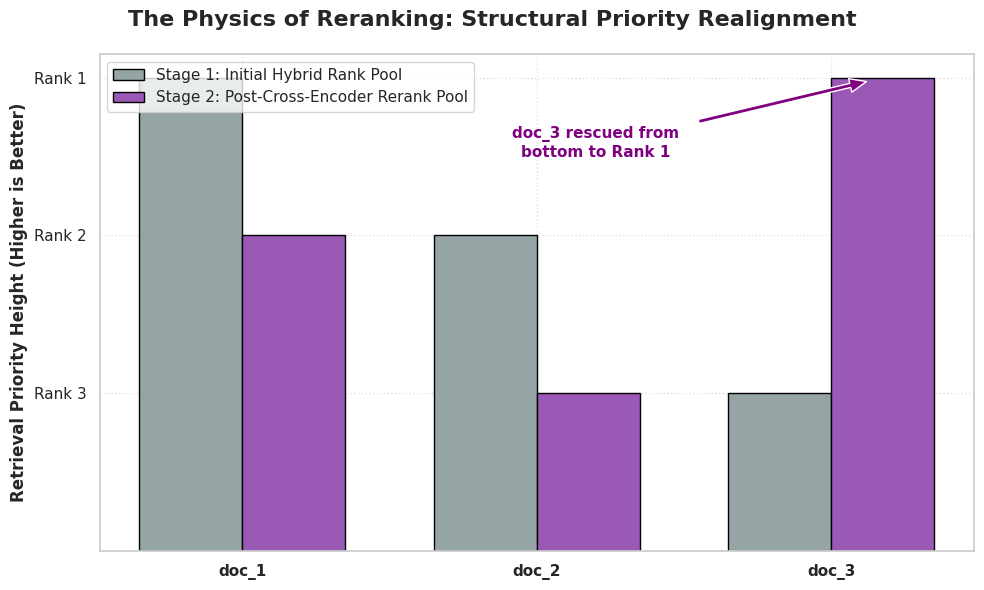

In [3]:
# Data extraction for mapping profiles
doc_ids = [d["id"] for d in stage_1_candidates]
initial_positions = [4 - d["initial_rank"] for d in stage_1_candidates] # Invert for plotting height

# Map final positions based on our sorted reranked pool
final_ranked_ids = [item[0] for item in reranked_pool]
final_positions = [4 - (final_ranked_ids.index(d_id) + 1) for d_id in doc_ids]

x = np.arange(len(doc_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("The Physics of Reranking: Structural Priority Realignment", fontsize=16, fontweight='bold')

rects1 = ax.bar(x - width/2, initial_positions, width, label='Stage 1: Initial Hybrid Rank Pool', color='#95a5a6', edgecolor='black')
rects2 = ax.bar(x + width/2, final_positions, width, label='Stage 2: Post-Cross-Encoder Rerank Pool', color='#9b59b6', edgecolor='black')

ax.set_ylabel('Retrieval Priority Height (Higher is Better)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(doc_ids, fontsize=11, fontweight='bold')
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Rank 3', 'Rank 2', 'Rank 1'], fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

# Add directional trend arrows manually to show structural path shift
ax.annotate('doc_3 rescued from\nbottom to Rank 1', 
            xy=(2 + width/2, 3), xytext=(1.2, 2.5),
            arrowprops=dict(facecolor='purple', shrink=0.08, headwidth=10, width=3),
            fontsize=11, fontweight='bold', color='purple', ha='center')

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

### The Two-Tier Executive Hiring Funnel

Imagine a global tech conglomerate looking to hire a highly specialized Chief Information Security Officer (CISO). They receive **10,000 résumés**.

* **Stage 1: The HR Keyword Filter (Bi-Encoder / Sparse Match)**: An HR assistant (or an automated applicant tracking database) scans all 10,000 résumés in a couple of hours. They look for explicit certifications, degree titles, and standard keyword clusters (*"10+ years experience", "Computer Science"*). They quickly slash the pile down from 10,000 to **5 target candidates**. This phase is fast and cheap, but it evaluates resumes in isolation. It completely misses a candidate whose résumé uses unorthodox phrasing but who actually managed a massive cyber warfare defense perimeter.
* **Stage 2: The Deep Boardroom Panel (The Cross-Encoder Reranker)**: The 5 final candidates are brought into a room for a grueling, 6-hour interactive evaluation loop with the CEO, the CTO, and the Board of Directors. The board evaluates the candidate interactively, asking complex conditional questions, evaluating body language, and testing deep problem-solving structures. The candidate who was originally ranked #5 by the cheap resume filter turns out to be an absolute genius under interactive cross-examination, while candidate #1 was just good at keyword-stuffing.

The board places Candidate #5 at Rank 1 and extends the job offer. You successfully filtered scale using Stage 1, and unlocked precision using Stage 2.